In [42]:
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sys.path.append(r"D:/Football Project/src")

import feature_lists as fl

In [43]:
df=pd.read_csv('../../../data/processed/major_leagues/EWMA_Major_Leagues.csv')

In [44]:
df=df[df['position']=='Goalkeepers']

In [45]:
df=df.drop(columns=fl.attacking_features_z)

In [46]:
df=df.drop(columns=[
    'rating_zscore',
    'countrating_zscore',
    'totalrating_zscore',
])

In [47]:
existing_cols_to_drop = [col for col in fl.volume_zscore_cols if col in df.columns]
df = df.drop(columns=existing_cols_to_drop)

In [48]:
df.shape

(387, 87)

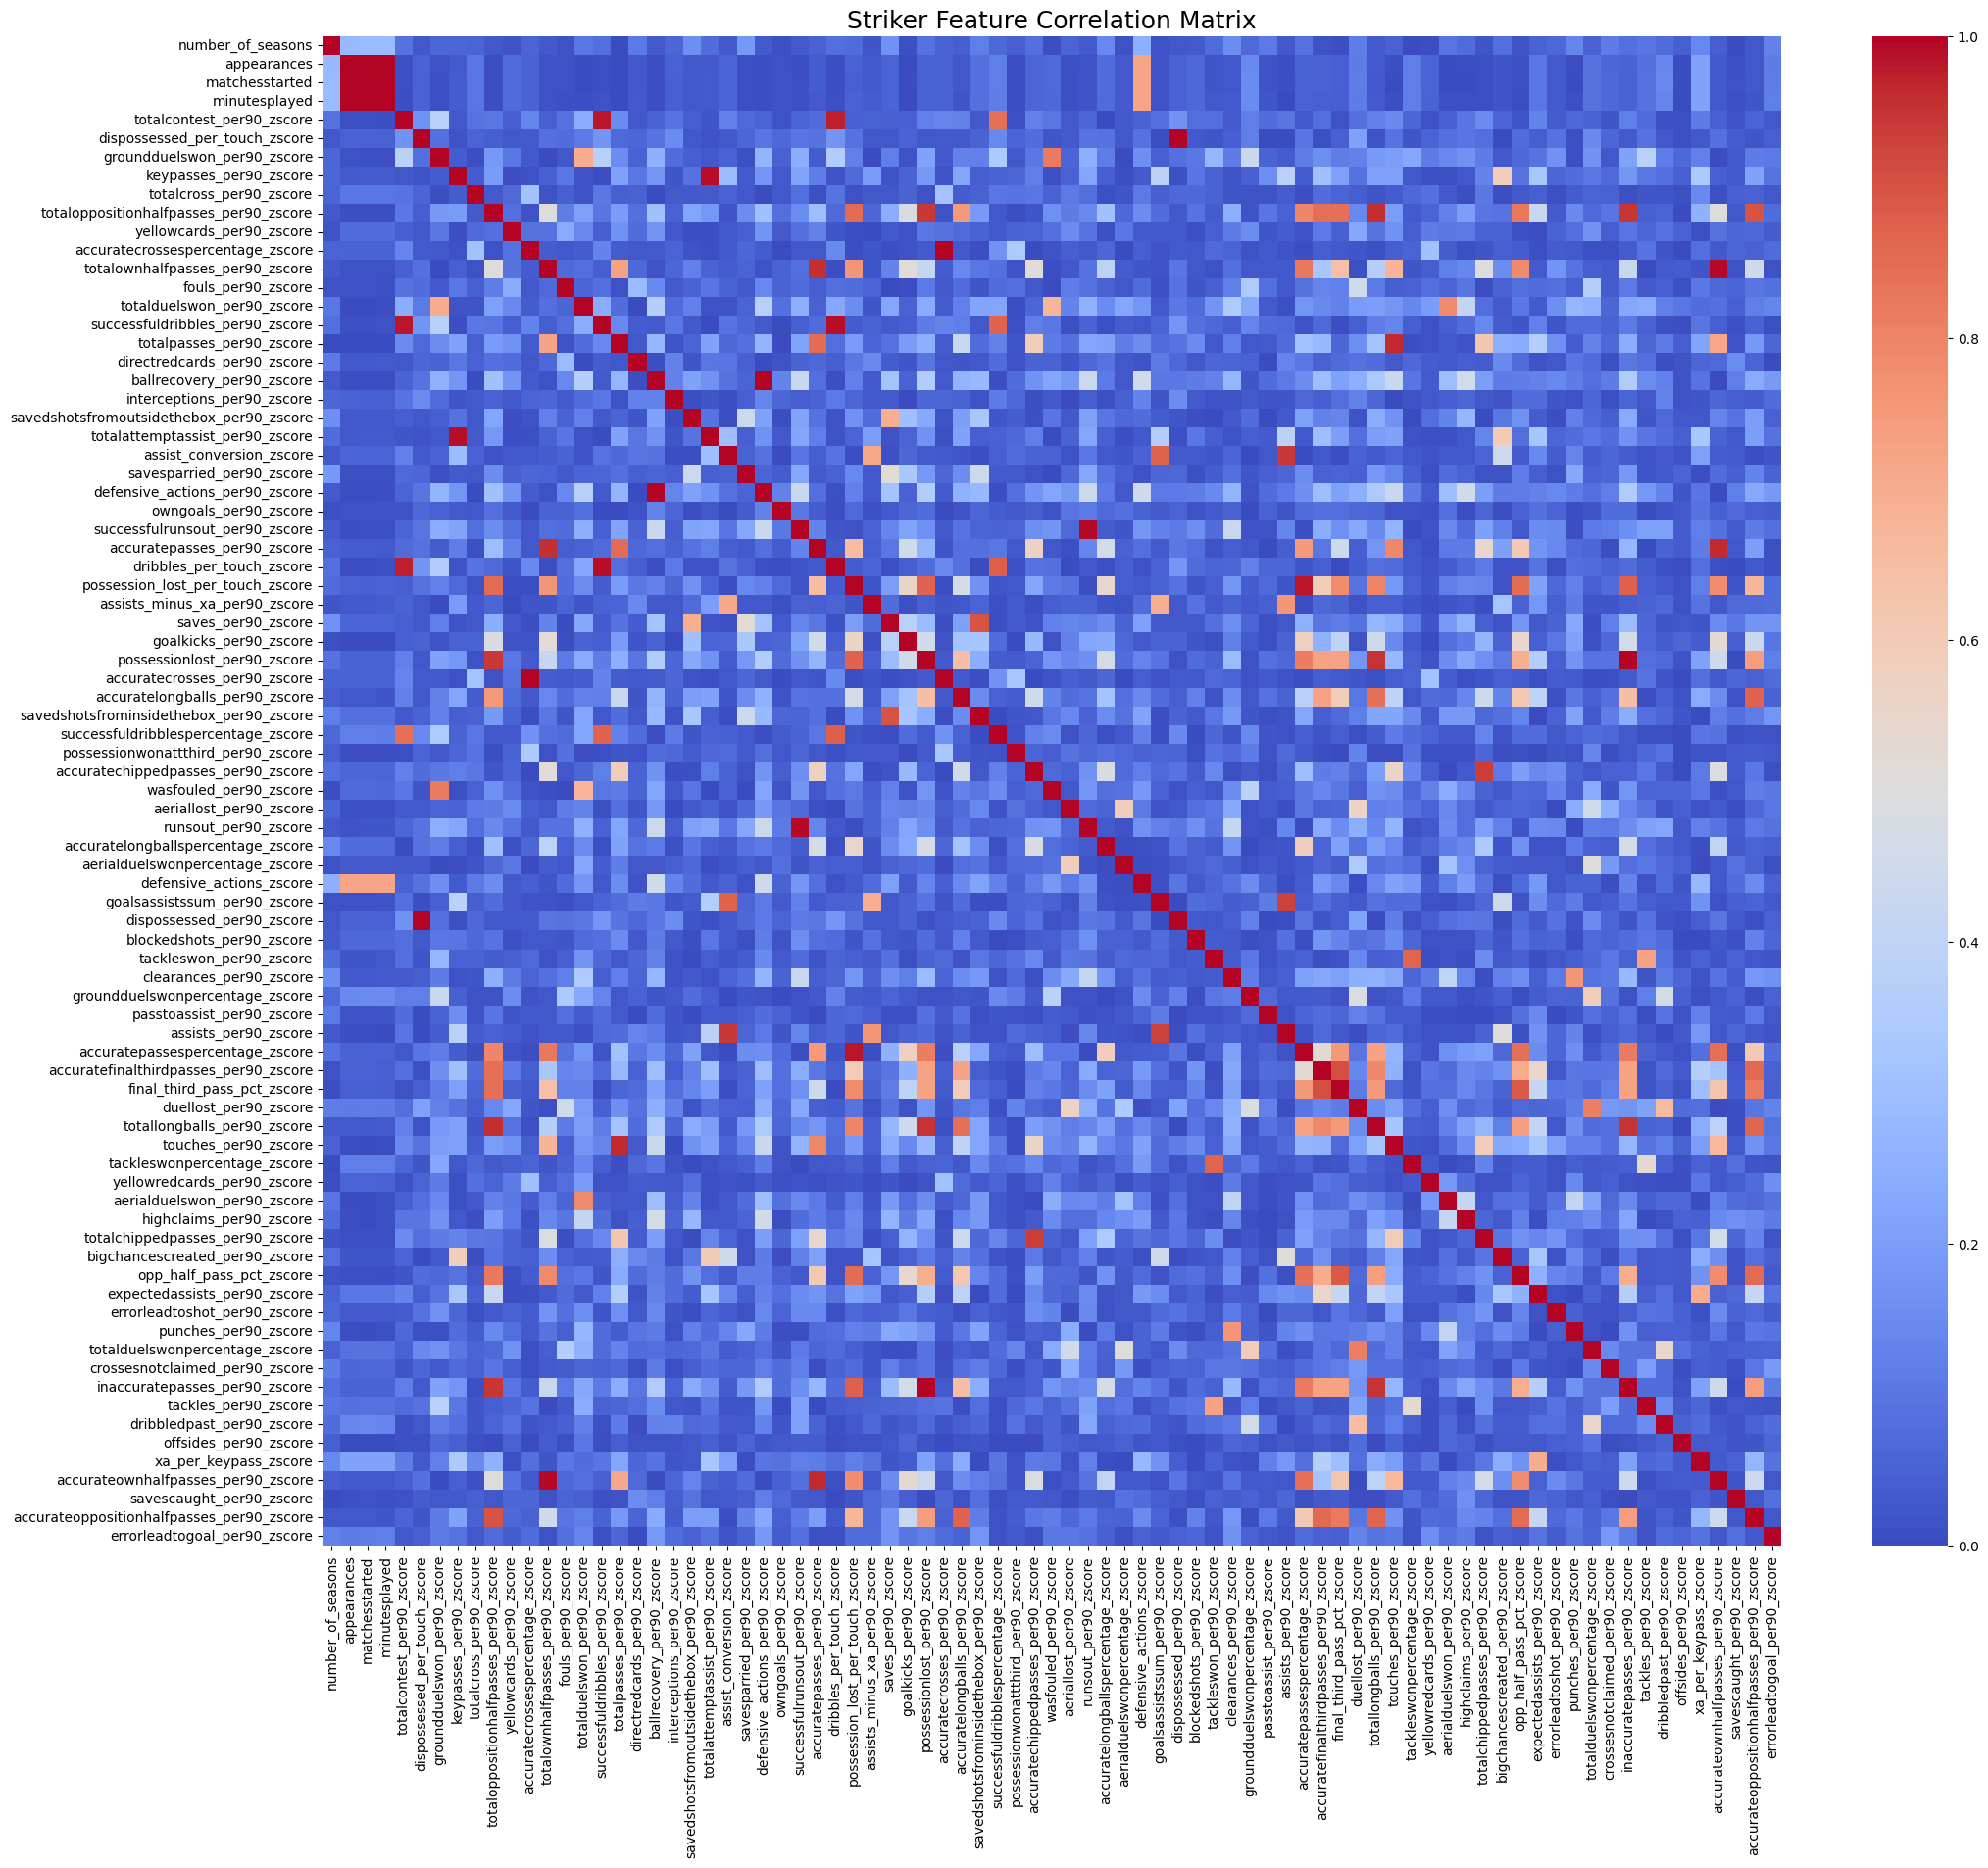

In [49]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [50]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,accuratecrossespercentage_zscore,accuratecrosses_per90_zscore,0.999682
1,ballrecovery_per90_zscore,defensive_actions_per90_zscore,0.999436
2,appearances,matchesstarted,0.999398
3,possessionlost_per90_zscore,inaccuratepasses_per90_zscore,0.999088
4,matchesstarted,minutesplayed,0.997394
5,appearances,minutesplayed,0.997338
6,dispossessed_per_touch_zscore,dispossessed_per90_zscore,0.996518
7,totalownhalfpasses_per90_zscore,accurateownhalfpasses_per90_zscore,0.995090
8,successfulrunsout_per90_zscore,runsout_per90_zscore,0.994497
9,successfuldribbles_per90_zscore,dribbles_per_touch_zscore,0.991216


In [51]:
df=df.drop(columns=[
    "accuratecrossespercentage_zscore", "accuratecrosses_per90_zscore",
    "defensive_actions_per90_zscore", "totalattemptassist_per90_zscore",
    "keypasses_per90_zscore", "dribbles_per_touch_zscore",
    "successfuldribblespercentage_zscore", "successfuldribbles_per90_zscore",
    "totalcontest_per90_zscore", "assist_conversion_zscore",
    "assists_per90_zscore", "goalsassistssum_per90_zscore",
    "tackleswonpercentage_zscore", "wasfouled_per90_zscore",
    "duellost_per90_zscore", "totalduelswonpercentage_zscore",
    "totalownhalfpasses_per90_zscore", "accurateownhalfpasses_per90_zscore",
    "totalpasses_per90_zscore", "totaloppositionhalfpasses_per90_zscore",
    "accurateoppositionhalfpasses_per90_zscore", "accuratefinalthirdpasses_per90_zscore",
    "final_third_pass_pct_zscore", "opp_half_pass_pct_zscore",
    "accuratepassespercentage_zscore", "possessionlost_per90_zscore",
    "inaccuratepasses_per90_zscore", "totallongballs_per90_zscore",
    "totalchippedpasses_per90_zscore", "savedshotsfrominsidethebox_per90_zscore",
    "dispossessed_per90_zscore",'runsout_per90_zscore','bigchancescreated_per90_zscore',
    'totalcross_per90_zscore','groundduelswon_per90_zscore','groundduelswonpercentage_zscore'
])

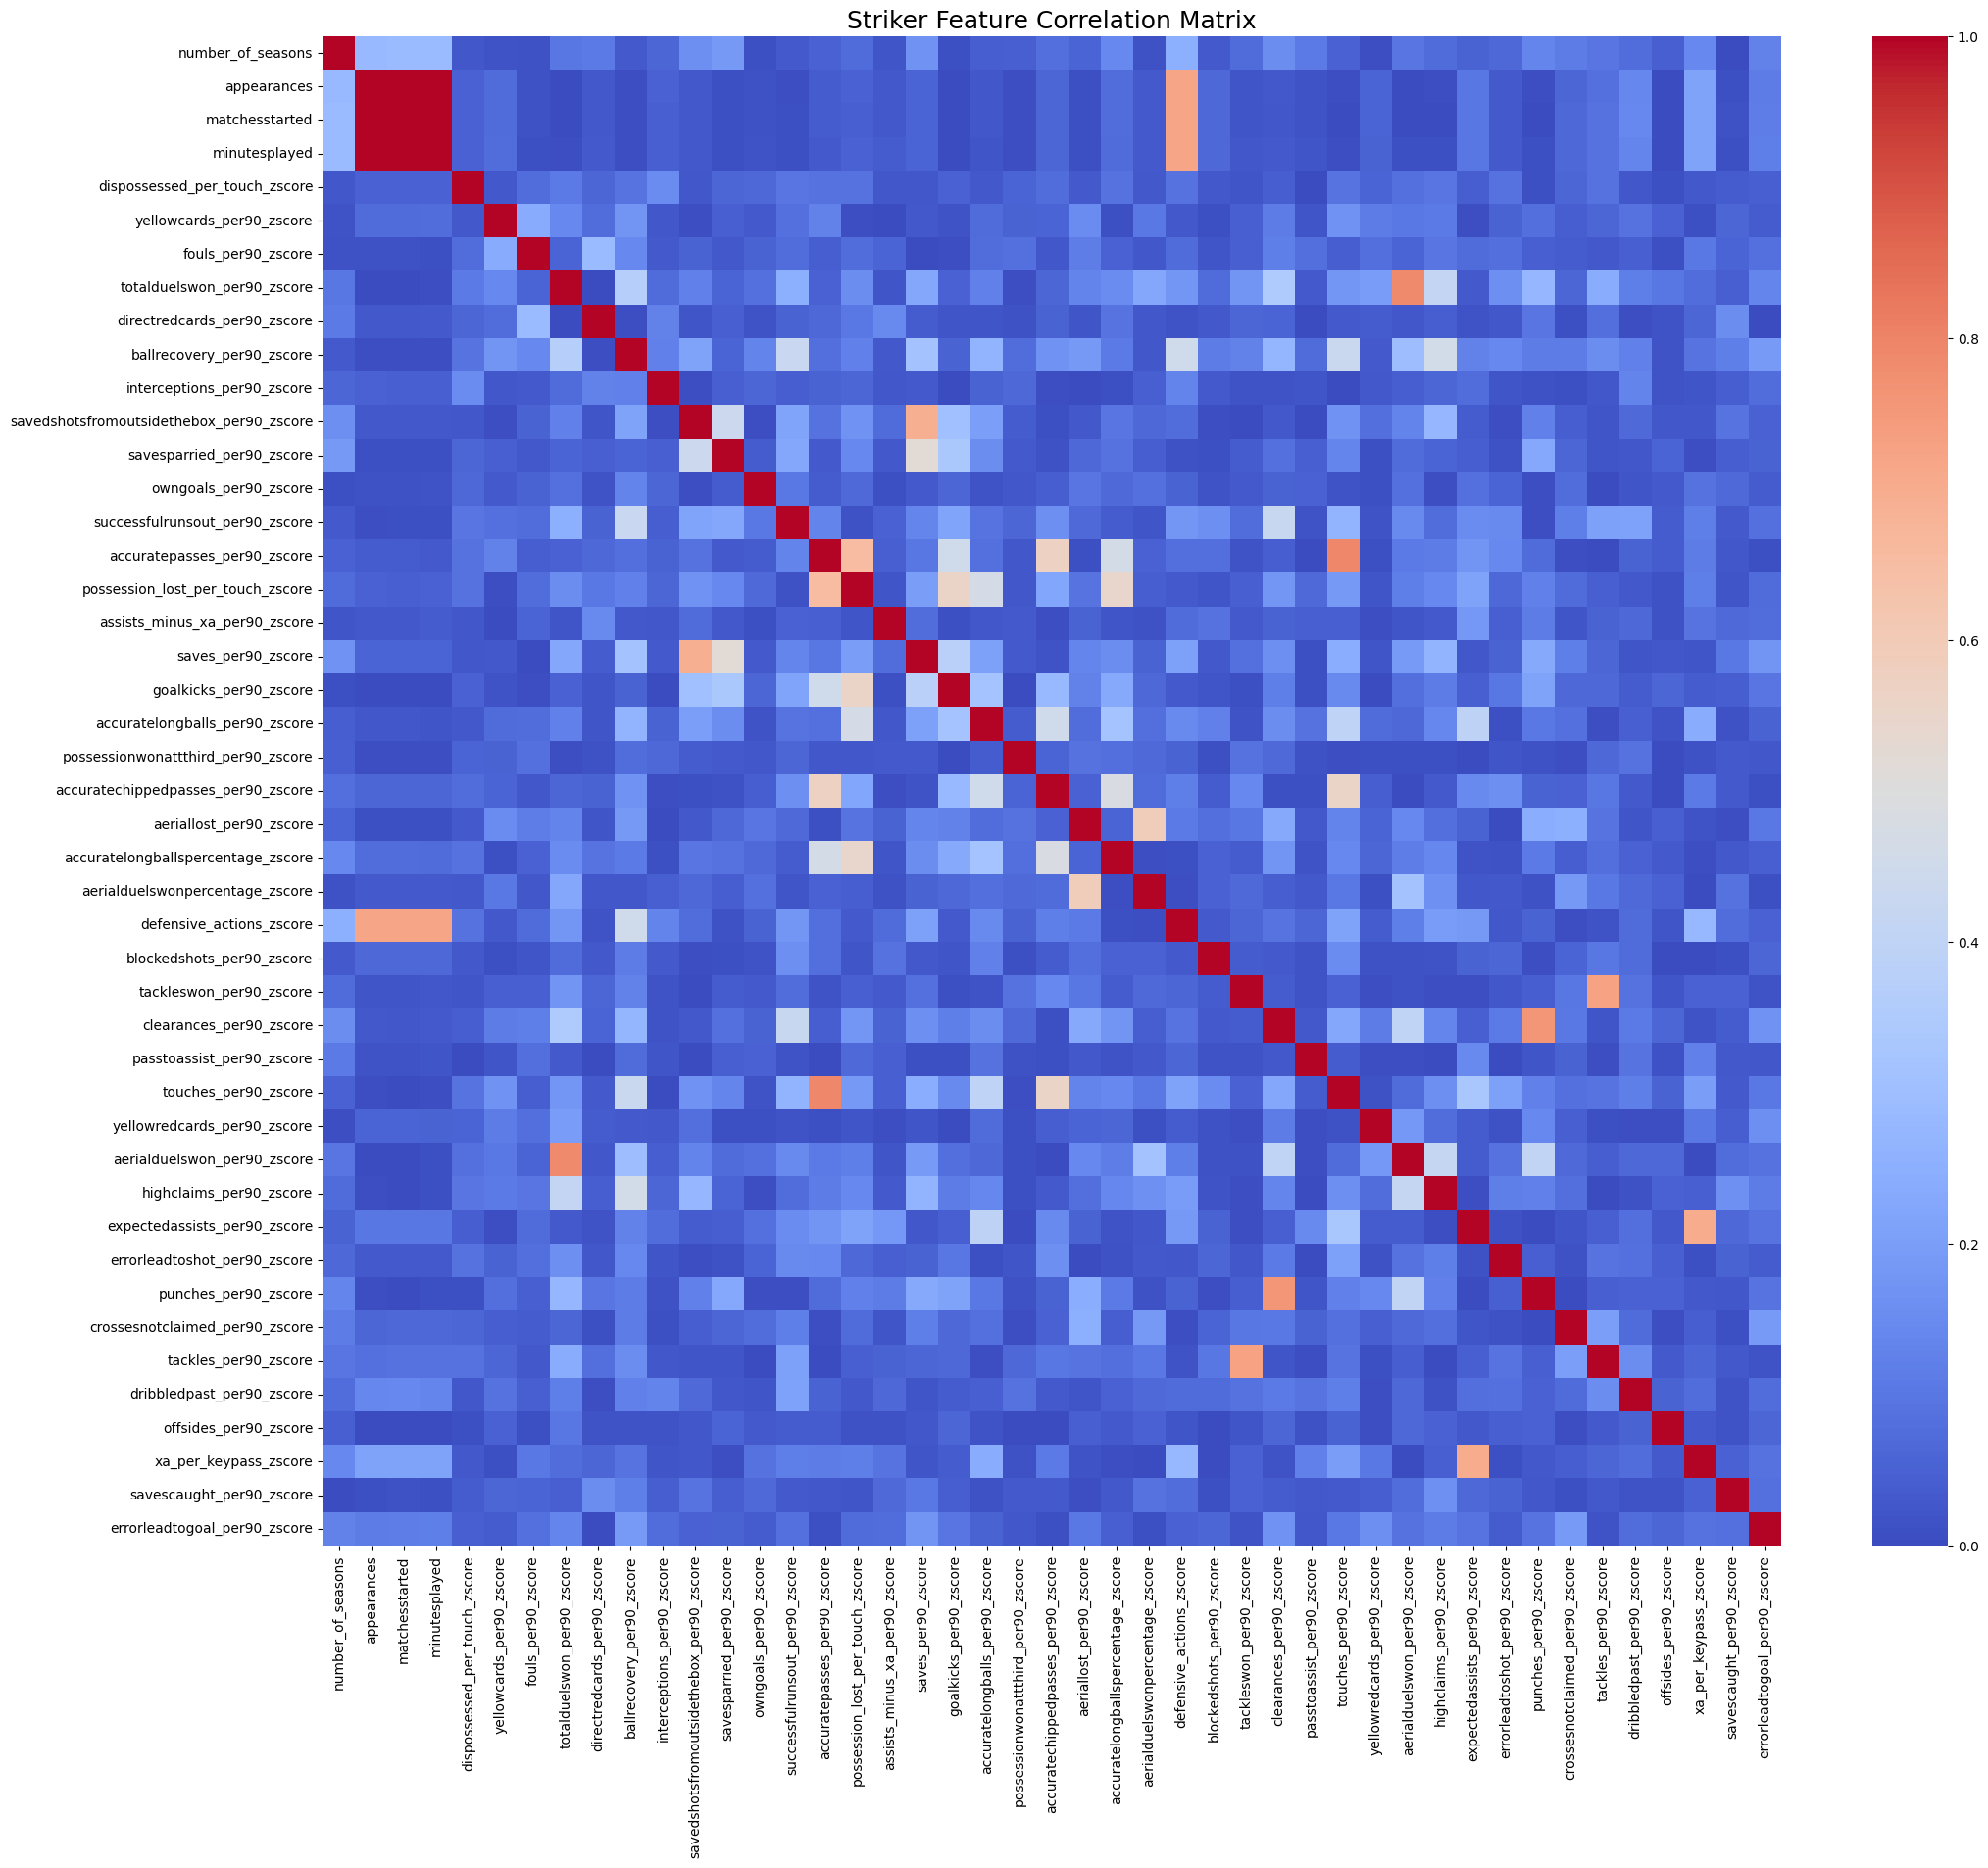

In [52]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [53]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,appearances,matchesstarted,0.999398
1,matchesstarted,minutesplayed,0.997394
2,appearances,minutesplayed,0.997338


In [54]:
df.shape

(387, 51)

In [55]:
df.columns.to_list()

['player id',
 'player',
 'team id',
 'team',
 'league',
 'position',
 'number_of_seasons',
 'appearances',
 'matchesstarted',
 'minutesplayed',
 'dispossessed_per_touch_zscore',
 'yellowcards_per90_zscore',
 'fouls_per90_zscore',
 'totalduelswon_per90_zscore',
 'directredcards_per90_zscore',
 'ballrecovery_per90_zscore',
 'interceptions_per90_zscore',
 'savedshotsfromoutsidethebox_per90_zscore',
 'savesparried_per90_zscore',
 'owngoals_per90_zscore',
 'successfulrunsout_per90_zscore',
 'accuratepasses_per90_zscore',
 'possession_lost_per_touch_zscore',
 'assists_minus_xa_per90_zscore',
 'saves_per90_zscore',
 'goalkicks_per90_zscore',
 'accuratelongballs_per90_zscore',
 'possessionwonattthird_per90_zscore',
 'accuratechippedpasses_per90_zscore',
 'aeriallost_per90_zscore',
 'accuratelongballspercentage_zscore',
 'aerialduelswonpercentage_zscore',
 'defensive_actions_zscore',
 'blockedshots_per90_zscore',
 'tackleswon_per90_zscore',
 'clearances_per90_zscore',
 'passtoassist_per90_zsco

In [56]:
df.to_csv('../../../data/processed/major_leagues/Goalkeepers/EWMA_Major_Goalkeepers.csv',index=False)